# GSE116222初步分析
结肠组织上皮细胞样本，9个样本，3个来自HC，6个来自UC（其中3个为炎症区域，3个为非炎症区域）   
6UC 3HC
- UC11-UC16
- HC11-HC13

# 文件说明
- **文件名**: 4_GSE116222.h5ad  
- **存放位置**: 坚果云  `UC/scRNA-seq_data/data_qc/`  
- **生成日期**: 2025-10-22  
- **生成者**: Jiang Lai
- **对应脚本**: notebooks/1_preprocessing/4_GSE116222_preprocessing.ipynb  
- **内容说明**: 包含质控和去除双细胞后的数据集数据，保存为h5ad文件，方便后续合并时读取  

In [1]:
import scanpy as sc
import omicverse as ov
ov.plot_set(dpi=50)
ov.settings.verbose = 1 
ov.settings.cpu_gpu_mixed_init()

/home/future/miniconda3/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


🔬 Starting plot initialization...
🧬 Detecting CUDA devices…
✅ [GPU 0] NVIDIA GeForce RTX 5060 Ti
    • Total memory: 15.9 GB
    • Compute capability: 12.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 1.7.7   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

CPU-GPU mixed mode activated


## 读取表达矩阵类型数据

In [2]:
import pandas as pd
import os

data_dir = "/mnt/e/UC/scRNA-seq_RAW/4_GSE116222"
adatas = []

for file in sorted(os.listdir(data_dir)):
    if not file.endswith(".txt"):
        continue

    path = os.path.join(data_dir, file)
    sample = os.path.splitext(file)[0]

    df = pd.read_csv(path, sep="\t", index_col=0)
    ad = sc.AnnData(df.T)
    sc.pp.filter_cells(ad, min_genes=200)
    sc.pp.filter_genes(ad, min_cells=3)

    #ad.obs['GSM_id'] = sample
    #ad.obs_names = [f"{sample}_{x}" for x in ad.obs_names]

    adatas.append(ad)

adata = sc.concat(adatas, merge='same')

filtered out 8 cells that have less than 200 genes expressed
filtered out 36081 genes that are detected in less than 3 cells


In [3]:
adata

AnnData object with n_obs × n_vars = 11167 × 22609
    obs: 'n_genes'
    var: 'n_cells'

In [4]:
adata.obs.head()

,n_genes
AAACCTGGTAATCGTC-A1,2110
AAACGGGAGCTTTGGT-A1,1354
AAACGGGTCTGGTATG-A1,806
AAAGTAGAGAACTGTA-A1,1184
AAAGTAGCAGGGAGAG-A1,1539


In [10]:
import pandas as pd

# 1️⃣ 提取 group（根据细胞名中的 A1/B2/C3）
adata.obs["group"] = (
    adata.obs_names.to_series()
    .str.extract(r"([A-Z]\d+)", expand=False)
    .str.strip()
)

# 2️⃣ group → id 映射
id_map = {
    "A1": "HC11", "A2": "UC14", "A3": "UC11",
    "B1": "HC12", "B2": "UC15", "B3": "UC12",
    "C1": "HC13", "C2": "UC16", "C3": "UC13"
}
adata.obs["id"] = adata.obs["group"].map(id_map)

# 3️⃣ id → GSM 映射
gsm_map = {
    "UC11": "GSM3214201",
    "UC14": "GSM3214202",
    "HC11": "GSM3214203",
    "UC12": "GSM3214204",
    "UC15": "GSM3214205",
    "HC12": "GSM3214206",
    "UC13": "GSM3214207",
    "UC16": "GSM3214208",
    "HC13": "GSM3214209"
}
adata.obs["GSM"] = adata.obs["id"].map(gsm_map)

# ✅ 检查结果
adata.obs[["group", "id", "GSM"]].head()


,group,id,GSM
AAACCTGGTAATCGTC-A1,A1,HC11,GSM3214203
AAACGGGAGCTTTGGT-A1,A1,HC11,GSM3214203
AAACGGGTCTGGTATG-A1,A1,HC11,GSM3214203
AAAGTAGAGAACTGTA-A1,A1,HC11,GSM3214203
AAAGTAGCAGGGAGAG-A1,A1,HC11,GSM3214203


In [11]:
adata.obs['id'].value_counts()

id
HC13    2146
UC15    1979
UC16    1724
HC12    1619
UC13    1273
UC12    1037
UC11     535
HC11     482
UC14     372
Name: count, dtype: int64

## 预处理步骤
- QC: mito<0.2, UMI>500, genes>250, 去除双细胞
- HVG: Pearson方法，2000个
- PCA: 50个PCs
- neighbors: 最邻近数15，使用前50PCs
- leiden: resolution0.5

In [12]:
# QC
adata=ov.pp.qc(adata,
               tresh={'mito_perc': 0.2, 'nUMIs': 500, 'detected_genes': 250},
               doublets_method='scrublet',
               batch_key=None)
adata

⚙️ Using CPU/GPU mixed mode for QC...
NVIDIA CUDA GPUs detected:
📊 [CUDA 0] NVIDIA GeForce RTX 5060 Ti
    |||--------------------------- 2007/16311 MiB (12.3%)

🔍 Quality Control Analysis (CPU-GPU Mixed):
   Dataset shape: 11,167 cells × 22,609 genes
   QC mode: seurat
   Doublet detection: scrublet
   Mitochondrial genes: MT-

📊 Step 1: Calculating QC Metrics
   Mitochondrial genes (prefix 'MT-'): 15 found
   ✓ QC metrics calculated:
     • Mean nUMIs: 2184 (range: 406-3805)
     • Mean genes: 1737 (range: 205-5753)
     • Mean mitochondrial %: 0.0% (max: 0.1%)

🔧 Step 2: Quality Filtering (SEURAT)
   Thresholds: mito≤0.2, nUMIs≥500, genes≥250
   📊 Seurat Filter Results:
     • nUMIs filter (≥500): 4 cells failed (0.0%)
     • Genes filter (≥250): 3 cells failed (0.0%)
     • Mitochondrial filter (≤0.2): 0 cells failed (0.0%)
   ✓ Combined QC filters: 4 cells removed (0.0%)

🎯 Step 3: Final Filtering
   Parameters: min_genes=200, min_cells=3
   Ratios: max_genes_ratio=1, max_cells_ra

AnnData object with n_obs × n_vars = 11113 × 22609
    obs: 'n_genes', 'group', 'id', 'GSM', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet'
    var: 'n_cells', 'mt'
    uns: 'scrublet', 'status', 'status_args', 'REFERENCE_MANU'

## 保存质控后数据（去除双细胞）

In [13]:
output_dir = "/mnt/c/Users/Future/Nutstore/1/UC/scRNA-seq_data/data_qc/"
os.makedirs(output_dir, exist_ok=True)
adata.write_h5ad(os.path.join(output_dir, "4_GSE116222.h5ad"), compression='gzip')

In [14]:
# HVG
adata=ov.pp.preprocess(adata,
                       mode='shiftlog|pearson',
                       n_HVGs=2000,
                       target_sum=50*1e4)

adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]

# PCA
ov.pp.scale(adata)
ov.pp.pca(adata,layer='scaled',n_pcs=50)

# Embedding the neighborhood graph
ov.pp.neighbors(adata, 
                n_neighbors=15, 
                n_pcs=50,
                use_rep='scaled|original|X_pca')

# UMAP
ov.pp.umap(adata)

# Clustering
ov.pp.leiden(adata,resolution=0.7)

Begin robust gene identification
After filtration, 22609/22609 genes are kept.     Among 22609 genes, 22609 genes are robust.
End of robust gene identification.
Begin size normalization: shiftlog and HVGs selection pearson
normalizing counts per cell
The following highly-expressed genes are not considered during normalization factor computation:
[]
    finished (0:00:02)
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'highly_variable_nbatches', int vector (adata.var)
    'highly_variable_intersection', boolean vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'residual_variances', float vector (adata.var)
Time to analyze data in cpu: 17.609137058258057 seconds.
End of size normalization: shiftlog and HVGs selection pearson
🚀 Using GPU to calculate PCA...
NVIDIA CUDA GPUs detected:
📊 [CUDA 0] NVIDIA GeForce RTX 5060 Ti
    |||||||---

In [15]:
adata

AnnData object with n_obs × n_vars = 11113 × 2000
    obs: 'n_genes', 'group', 'id', 'GSM', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet', 'leiden'
    var: 'n_cells', 'mt', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_features'
    uns: 'scrublet', 'status', 'status_args', 'REFERENCE_MANU', 'log1p', 'hvg', 'pca', 'scaled|original|pca_var_ratios', 'scaled|original|cum_sum_eigenvalues', 'neighbors', 'umap', 'leiden'
    obsm: 'X_pca', 'scaled|original|X_pca', 'X_umap'
    varm: 'PCs', 'scaled|original|pca_loadings'
    layers: 'counts', 'scaled'
    obsp: 'distances', 'connectivities'

In [16]:
adata.obs['id'].value_counts()

id
HC13    2135
UC15    1972
UC16    1720
HC12    1609
UC13    1264
UC12    1030
UC11     532
HC11     481
UC14     370
Name: count, dtype: int64

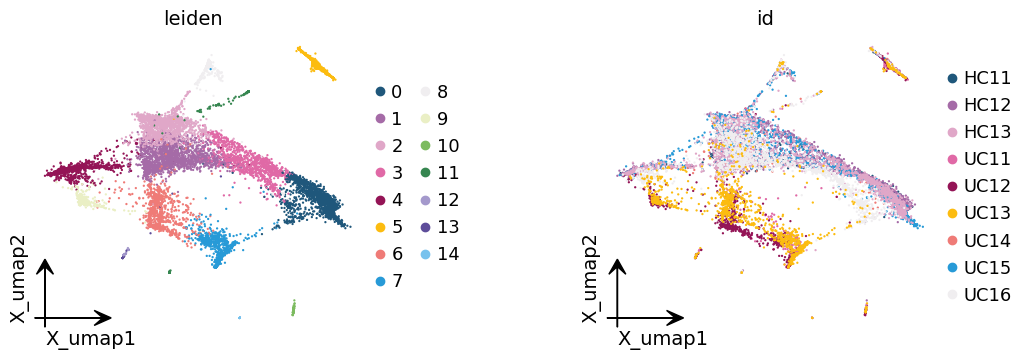

In [17]:
# 可视化查看聚类和样本分布
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'id'],
                frameon='small',
                wspace=0.5)

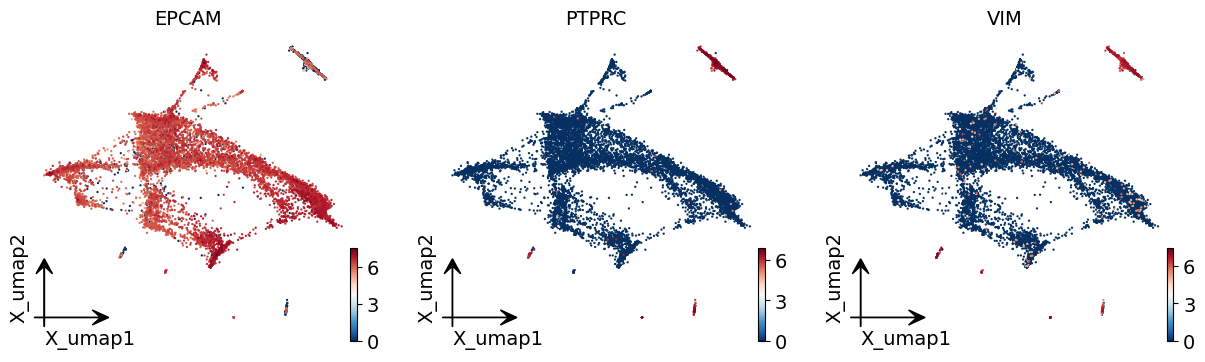

In [18]:
# 粗略查看上皮、免疫、基质细胞
ov.pl.embedding(adata,
                basis='X_umap',
                color=['EPCAM', 'PTPRC', 'VIM'],
                frameon='small')

In [19]:
# 获取每个细胞群的基因
all_markers = ov.single.get_celltype_marker(adata,
                                            clustertype='leiden',
                                            rank=True,
                                            key='rank_genes_groups',
                                            foldchange=1,
                                            topgenenumber=10)
all_markers

...get cell type marker
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:23)


{'0': ['PLAC8',
  'PRDX6',
  'FXYD3',
  'AQP8',
  'GUCA2B',
  'PRAP1',
  'MS4A12',
  'CEACAM7',
  'SLC26A3',
  'GUCA2A'],
 '1': ['MRPL12',
  'METTL12',
  'HIST1H4C',
  'HES1',
  'MAFB',
  'SOX4',
  'SNHG5',
  'RN7SK',
  'STARD10',
  'HEXIM1'],
 '10': ['CD79A',
  'CD37',
  'HLA-DPA1',
  'HLA-DQB1',
  'LAPTM5',
  'HLA-DPB1',
  'CXCR4',
  'CD74',
  'HLA-DRA',
  'HLA-DQA1'],
 '11': ['CRYBA2',
  'PCSK1N',
  'MS4A8',
  'INSM1',
  'SCGN',
  'CPE',
  'FEV',
  'TUBA1A',
  'CHGA',
  'SCG5'],
 '12': ['HLA-DRB1',
  'LST1',
  'TYROBP',
  'HLA-DPA1',
  'HLA-DPB1',
  'LYZ',
  'AIF1',
  'CD74',
  'HLA-DRA',
  'HLA-DQA1'],
 '13': ['IGJ',
  'CD79A',
  'IGKC',
  'LGALS1',
  'SEC11C',
  'SSR4',
  'FKBP11',
  'DERL3',
  'IGHA1',
  'MZB1'],
 '14': ['SRGN',
  'TYROBP',
  'ALOX5AP',
  'TPSAB1',
  'CPA3',
  'S100A4',
  'HPGDS',
  'VIM',
  'ANXA1',
  'TPSB2'],
 '2': ['RPL17',
  'RANBP1',
  'C1QBP',
  'RARRES2',
  'LRRC75A-AS1',
  'GMNN',
  'RPL36A',
  'RPL5',
  'PPP1R1B',
  'RPL22'],
 '3': ['S100A14',
  'CA1',


In [23]:
os.environ['AGI_API_KEY'] = 'sk-ff0dc715f640466393e6aa71c9da6848'
result = ov.single.gptcelltype(all_markers,
                               tissuename='colon',
                               speciename='human',
                               model='qwen-plus',
                               provider='qwen',
                               topgenenumber=10)
result

Note: AGI API key found: returning the cell type annotations.
Note: It is always recommended to check the results returned by GPT-4 in case of AI hallucination, before going to downstream analysis.


{'0': 'Enterocyte',
 '1': 'Proliferative epithelial cell',
 '10': 'B cell',
 '11': 'Enteroendocrine cell',
 '12': 'Myeloid cell',
 '13': 'Plasma cell',
 '14': 'Mast cell',
 '2': 'Ribosomal protein expressing cell',
 '3': 'Colonocyte',
 '4': 'Goblet cell',
 '5': 'T cell',
 '6': 'Stem cell',
 '7': 'Enterocyte',
 '8': 'Tuft cell',
 '9': 'Goblet cell'}

In [24]:
# 添加识别结果到obs
adata.obs['gpt_celltype'] = adata.obs['leiden'].map(result).astype('category')

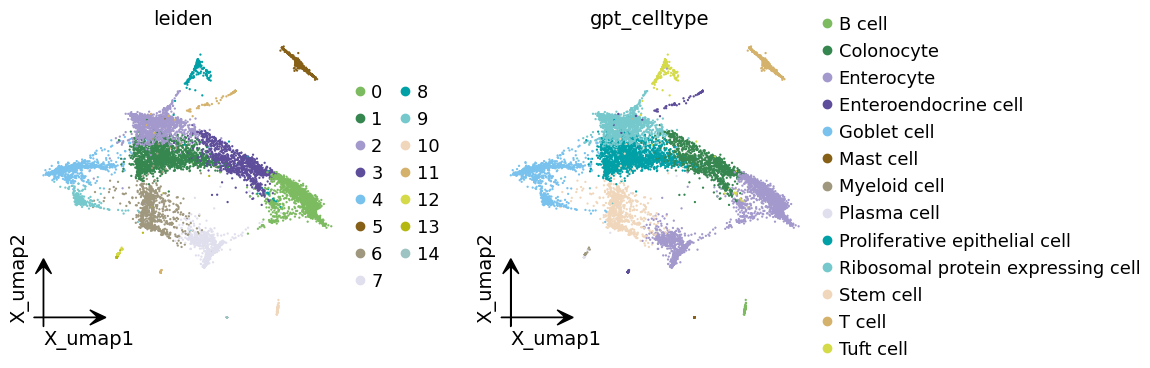

In [26]:
# 可视化查看结果
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'gpt_celltype'],
                # legend_loc='on data',
                frameon='small',
                legend_fontoutline=0.5,
                palette=ov.utils.palette()[10:],
                wspace=0.3)

In [25]:
# 统计每种细胞类型数量及占比
celltype_counts = adata.obs['gpt_celltype'].value_counts(normalize=True) * 100
print(celltype_counts)

gpt_celltype
Enterocyte                           23.009088
Proliferative epithelial cell        16.278233
Ribosomal protein expressing cell    15.027445
Goblet cell                          12.678845
Colonocyte                            9.691352
T cell                                8.017637
Stem cell                             7.774678
Tuft cell                             3.014488
B cell                                2.222622
Enteroendocrine cell                  1.241789
Myeloid cell                          0.368937
Plasma cell                           0.359939
Mast cell                             0.314946
Name: proportion, dtype: float64


# 总结
疑问：
- GPT注释的结果当中，存在上皮细胞之外的其他细胞类型
- 是注释不准？还是本身混杂了其他细胞？